# Track B 070103: v2 OOD / Mislabel Scoring

이 노트북은 `trackB_070102`의 저장된 ResNet-18 embedding과 v1 detail CSV를 재사용해 TrackB v2 점수를 만든다.

목표는 다음과 같다.

- OOD는 confidence를 제거하고 embedding kNN density 중심으로 재정의한다.
- k=5, 10, 20의 mean kNN cosine을 비교하고, 기본 OOD 후보는 k=10으로 둔다.
- raw OOD rank를 tail calibration(q90~q99, q95~q995)으로 변환한다.
- mislabel은 raw model disagreement를 유지하되 confidence 영향은 약화한다.
- kNN label disagreement는 1-NN이 아니라 k=5/10/20 평균을 계산하고, 기본 후보는 k=10을 쓴다.
- dup_score는 v1 값을 유지한다.
- v1/v2 비교, top50 overlap, top50 이미지 export, score-bin sample export, outlier 진단 플롯을 한 노트북에 포함한다.


In [1]:
from pathlib import Path
from datetime import datetime
import json
import math
import os
import re
import shutil

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from IPython.display import display

ImageFile.LOAD_TRUNCATED_IMAGES = True

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)


## 0. 경로 설정

v2 출력은 v1 폴더와 분리한다. `outputs/trackB_070103_v2`가 이미 비어 있지 않으면 timestamp가 붙은 새 폴더를 사용해 기존 결과를 덮어쓰지 않는다.


In [2]:
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Quest02":
    PROJECT_DIR = Path("/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02")

TRACK_B_ROOT = PROJECT_DIR / "data" / "RS18B"
TRACK_B_SAMPLE_PATH = TRACK_B_ROOT / "sample_submission.csv"
TRACK_B_TRAIN_DIR = TRACK_B_ROOT / "train"

V1_OUTPUT_DIR = PROJECT_DIR / "outputs" / "trackB_070102"
V1_DETAIL_PATH = V1_OUTPUT_DIR / "trackB_resnet18_scores_detail.csv"
V1_EMBEDDINGS_PATH = V1_OUTPUT_DIR / "resnet18_embeddings.npy"
V1_EMBEDDING_IDS_PATH = V1_OUTPUT_DIR / "resnet18_embedding_ids.csv"

BASE_OUTPUT_DIR = PROJECT_DIR / "outputs" / "trackB_070103_v2"
OUTPUT_DIR = BASE_OUTPUT_DIR
if OUTPUT_DIR.exists() and any(OUTPUT_DIR.iterdir()):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = PROJECT_DIR / "outputs" / f"trackB_070103_v2_{timestamp}"

VIS_DIR = OUTPUT_DIR / "visualizations"
TOP50_DIR = OUTPUT_DIR / "top50_images"
SCORE_SAMPLE_DIR = OUTPUT_DIR / "score_bin_sample_exports"
TABLE_DIR = OUTPUT_DIR / "tables"

for path in [OUTPUT_DIR, VIS_DIR, TOP50_DIR, SCORE_SAMPLE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DETAIL_V2_PATH = OUTPUT_DIR / "trackB_v2_scores_detail.csv"
SUBMISSION_DEFAULT_PATH = OUTPUT_DIR / "submissionB.csv"
SUBMISSION_ADD_PATH = OUTPUT_DIR / "submissionB_v2_add.csv"
SUBMISSION_MUL_PATH = OUTPUT_DIR / "submissionB_v2_mul.csv"
CONFIG_PATH = OUTPUT_DIR / "trackB_v2_score_config.json"
TOP50_INDEX_PATH = TOP50_DIR / "top50_image_index.csv"
SCORE_SAMPLE_INDEX_PATH = SCORE_SAMPLE_DIR / "score_sample_index.csv"

required_paths = [TRACK_B_SAMPLE_PATH, TRACK_B_TRAIN_DIR, V1_DETAIL_PATH, V1_EMBEDDINGS_PATH, V1_EMBEDDING_IDS_PATH]
for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(path)

print("PROJECT_DIR:", PROJECT_DIR)
print("V1_OUTPUT_DIR:", V1_OUTPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02
V1_OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101


## 1. v1 산출물과 embedding 로드

v1 detail CSV에는 기존 prediction, dup, OOD, mislabel 신호가 들어 있다. v2는 여기에 kNN density/label disagreement 기반 컬럼을 추가한다.


In [3]:
EXPECTED_COLUMNS = ["id", "mislabel_score", "dup_score", "ood_score"]

sample = pd.read_csv(TRACK_B_SAMPLE_PATH)
if sample.columns.tolist() != EXPECTED_COLUMNS:
    raise ValueError(f"sample_submission columns mismatch: {sample.columns.tolist()}")
sample["id"] = sample["id"].astype(str)

v1_detail_df = pd.read_csv(V1_DETAIL_PATH)
v1_detail_df["id"] = v1_detail_df["id"].astype(str)

embedding_ids = pd.read_csv(V1_EMBEDDING_IDS_PATH)
embedding_ids["id"] = embedding_ids["id"].astype(str)
embeddings_raw = np.load(V1_EMBEDDINGS_PATH).astype(np.float32)

required_v1_columns = {
    "id", "path", "label", "pred_label", "pred_clean", "pred_dusty", "confidence",
    "dup_score", "resnet18_dup_score", "phash_dup_score", "nearest_phash_dist",
    "dup_source", "effective_nearest_id", "nearest_label", "label_conflict",
    "ood_score", "ood_score_raw", "mislabel_score", "disagreement",
}
missing_v1_columns = sorted(required_v1_columns - set(v1_detail_df.columns))
if missing_v1_columns:
    raise ValueError(f"Missing v1 detail columns: {missing_v1_columns}")

if len(v1_detail_df) != len(sample):
    raise ValueError("v1 detail row count mismatch")
if v1_detail_df["id"].tolist() != sample["id"].tolist():
    raise ValueError("v1 detail id order does not match sample_submission")
if embeddings_raw.shape[0] != len(embedding_ids):
    raise ValueError("embedding row count mismatch")

embedding_order = embedding_ids.set_index("id")["embedding_row"].to_dict()
if set(v1_detail_df["id"]) != set(embedding_order):
    raise ValueError("embedding ids do not cover v1 detail ids")

ordered_embedding_rows = [int(embedding_order[row_id]) for row_id in v1_detail_df["id"]]
embeddings = embeddings_raw[ordered_embedding_rows]

if embeddings.shape != (len(v1_detail_df), 512):
    raise ValueError(f"embedding shape mismatch: {embeddings.shape}")
if not np.isfinite(embeddings).all():
    raise ValueError("embeddings contain non-finite values")

score_df = v1_detail_df.copy()
score_df["ood_score_v1"] = pd.to_numeric(score_df["ood_score"], errors="coerce")
score_df["ood_score_raw_v1"] = pd.to_numeric(score_df["ood_score_raw"], errors="coerce")
score_df["mislabel_score_v1"] = pd.to_numeric(score_df["mislabel_score"], errors="coerce")
score_df["raw_model_disagreement_v1"] = pd.to_numeric(score_df["disagreement"], errors="coerce")
score_df["dup_score"] = pd.to_numeric(score_df["dup_score"], errors="coerce")

for col in ["label", "pred_label", "pred_clean", "pred_dusty", "confidence"]:
    score_df[col] = pd.to_numeric(score_df[col], errors="coerce")

label_array = score_df["label"].to_numpy(dtype=int)
id_array = score_df["id"].astype(str).to_numpy()
label_map = dict(zip(score_df["id"].astype(str), label_array))
path_map = dict(zip(score_df["id"].astype(str), score_df["path"]))

print("sample rows:", len(sample))
print("embedding shape:", embeddings.shape)
display(score_df[["id", "label", "pred_label", "pred_clean", "pred_dusty", "confidence", "dup_score", "ood_score_v1", "mislabel_score_v1"]].head())


sample rows: 1366
embedding shape: (1366, 512)


,id,label,pred_label,pred_clean,pred_dusty,confidence,dup_score,ood_score_v1,mislabel_score_v1
0,train_00000,0,0,0.984954,0.015046,0.969908,0.0,0.427379,0.008356
1,train_00001,1,1,0.000772,0.999228,0.998456,0.0,0.714788,0.000220
2,train_00002,0,0,0.996020,0.003980,0.992040,0.0,0.314056,0.002708
3,train_00003,1,1,0.051780,0.948220,0.896439,0.0,0.972182,0.001291
4,train_00004,1,0,0.761825,0.238175,0.523649,0.0,0.650805,0.139304


## 2. embedding cosine matrix와 kNN 계산

self diagonal을 `-inf`로 마스킹한 뒤 k=20까지 이웃을 구한다. 이후 k=5, 10, 20의 mean kNN cosine과 label disagreement 평균을 계산한다.


In [4]:
def l2_normalize(matrix, eps=1e-12):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.maximum(norms, eps)

MAX_K = 20
if len(score_df) <= MAX_K:
    raise ValueError("Not enough rows for k=20 nearest neighbors")

normalized_embeddings = l2_normalize(embeddings).astype(np.float32)
cosine_matrix = normalized_embeddings @ normalized_embeddings.T
self_sim_before_mask = np.diag(cosine_matrix).copy()
np.fill_diagonal(cosine_matrix, -np.inf)

candidate_idx = np.argpartition(-cosine_matrix, kth=MAX_K - 1, axis=1)[:, :MAX_K]
candidate_sim = np.take_along_axis(cosine_matrix, candidate_idx, axis=1)
sort_order = np.argsort(-candidate_sim, axis=1)
topk_idx = np.take_along_axis(candidate_idx, sort_order, axis=1)
topk_sim = np.take_along_axis(candidate_sim, sort_order, axis=1)

self_selected = int((topk_idx == np.arange(len(score_df))[:, None]).sum())
if self_selected != 0:
    raise ValueError("self index selected in top-k neighbors")
if not np.isfinite(topk_sim).all():
    raise ValueError("top-k similarities contain non-finite values")

for k in [1, 5, 10, 20]:
    score_df[f"mean_knn{k}_cos"] = topk_sim[:, :k].mean(axis=1)

score_df["embedding_knn1_id"] = id_array[topk_idx[:, 0]]
score_df["embedding_knn1_cos"] = topk_sim[:, 0]
score_df["embedding_knn1_label"] = label_array[topk_idx[:, 0]]

print("self similarity min/max before mask:", float(self_sim_before_mask.min()), float(self_sim_before_mask.max()))
print("self selected after mask:", self_selected)
display(score_df[["mean_knn1_cos", "mean_knn5_cos", "mean_knn10_cos", "mean_knn20_cos", "embedding_knn1_cos"]].describe().T)


self similarity min/max before mask: 0.9999996423721313 1.0000003576278687
self selected after mask: 0


,count,mean,std,min,25%,50%,75%,max
mean_knn1_cos,1366.0,0.854860,0.073043,0.668569,0.801288,0.835760,0.921515,0.999717
mean_knn5_cos,1366.0,0.808956,0.040086,0.635398,0.782687,0.811713,0.836528,0.904978
mean_knn10_cos,1366.0,0.792428,0.037667,0.617038,0.768794,0.796289,0.820457,0.877387
mean_knn20_cos,1366.0,0.777630,0.038949,0.603764,0.754517,0.783319,0.805845,0.863125
embedding_knn1_cos,1366.0,0.854860,0.073043,0.668569,0.801288,0.835760,0.921515,0.999717


## 3. OOD score v2

confidence는 OOD 계산에서 제거한다. `mean_knn10_cos`가 낮을수록 OOD가 높아지도록 rank를 만들고, q90~q99 tail calibration을 기본 `ood_score_v2`로 사용한다. q95~q995 calibration은 비교용으로 함께 저장한다.


In [5]:
def rank01(values, ascending=True):
    values = pd.Series(values).astype(float)
    if values.nunique(dropna=False) <= 1:
        return np.zeros(len(values), dtype=float)
    return values.rank(method="average", pct=True, ascending=ascending).to_numpy(dtype=float)


def clip01(values):
    return np.clip(np.asarray(values, dtype=float), 0.0, 1.0)


def tail_calibrate(raw_values, q_low=0.90, q_high=0.99):
    raw_values = np.asarray(raw_values, dtype=float)
    lo = float(np.quantile(raw_values, q_low))
    hi = float(np.quantile(raw_values, q_high))
    if hi <= lo:
        calibrated = np.zeros_like(raw_values, dtype=float)
    else:
        calibrated = clip01((raw_values - lo) / (hi - lo))
    return calibrated, lo, hi

for k in [5, 10, 20]:
    score_df[f"ood_raw_rank_knn{k}"] = rank01(score_df[f"mean_knn{k}_cos"], ascending=False)

score_df["ood_score_v2_raw"] = score_df["ood_raw_rank_knn10"]
ood_score_v2_q90_q99, ood_q90, ood_q99 = tail_calibrate(score_df["ood_score_v2_raw"], q_low=0.90, q_high=0.99)
ood_score_v2_q95_q995, ood_q95, ood_q995 = tail_calibrate(score_df["ood_score_v2_raw"], q_low=0.95, q_high=0.995)

score_df["ood_score_v2_q90_q99"] = ood_score_v2_q90_q99
score_df["ood_score_v2_q95_q995"] = ood_score_v2_q95_q995
score_df["ood_score_v2"] = score_df["ood_score_v2_q90_q99"]

print("OOD v2 default: k=10, q90~q99 tail calibration")
print("q90/q99:", ood_q90, ood_q99)
print("q95/q995:", ood_q95, ood_q995)
display(score_df[[
    "mean_knn5_cos", "mean_knn10_cos", "mean_knn20_cos",
    "ood_raw_rank_knn5", "ood_raw_rank_knn10", "ood_raw_rank_knn20",
    "ood_score_v1", "ood_score_v2_raw", "ood_score_v2", "ood_score_v2_q95_q995",
]].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995]).T)


OOD v2 default: k=10, q90~q99 tail calibration
q90/q99: 0.9000732064421669 0.9900073206442166
q95/q995: 0.9500366032210835 0.9950036603221083


,count,mean,std,min,50%,90%,95%,99%,99.5%,max
mean_knn5_cos,1366.0,0.808956,0.040086,0.635398,0.811713,0.858662,0.871062,0.895308,0.900131,0.904978
mean_knn10_cos,1366.0,0.792428,0.037667,0.617038,0.796289,0.838368,0.847217,0.860092,0.863438,0.877387
mean_knn20_cos,1366.0,0.777630,0.038949,0.603764,0.783319,0.822758,0.830449,0.843897,0.848362,0.863125
ood_raw_rank_knn5,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_raw_rank_knn10,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_raw_rank_knn20,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_score_v1,1366.0,0.499634,0.211868,0.037482,0.480234,0.814422,0.884370,0.976142,0.988104,0.997218
ood_score_v2_raw,1366.0,0.500366,0.288781,0.000732,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_score_v2,1366.0,0.055326,0.193139,0.000000,0.000000,0.002035,0.555556,0.998148,1.000000,1.000000
ood_score_v2_q95_q995,1366.0,0.027846,0.139966,0.000000,0.000000,0.000000,0.003053,0.888889,0.997650,1.000000


## 4. kNN label disagreement

기존 1-NN 방식은 보존하되 final mislabel에는 쓰지 않는다. k=5, 10, 20 이웃 라벨이 현재 라벨과 다른 비율을 평균으로 계산하고, 기본 후보는 `knn10_label_disagreement`로 둔다.


In [6]:
neighbor_labels = label_array[topk_idx]
label_mismatch = neighbor_labels != label_array[:, None]

score_df["knn1_label_disagreement"] = label_mismatch[:, :1].mean(axis=1)
for k in [5, 10, 20]:
    score_df[f"knn{k}_label_disagreement"] = label_mismatch[:, :k].mean(axis=1)

print("kNN label disagreement coverage:", len(score_df), "/", len(score_df))
display(score_df[[
    "knn1_label_disagreement", "knn5_label_disagreement", "knn10_label_disagreement", "knn20_label_disagreement",
]].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T)


kNN label disagreement coverage: 1366 / 1366


,count,mean,std,min,50%,75%,90%,95%,99%,max
knn1_label_disagreement,1366.0,0.090044,0.286350,0.0,0.0,0.00,0.0,1.000,1.0000,1.0
knn5_label_disagreement,1366.0,0.090483,0.223486,0.0,0.0,0.00,0.2,0.800,1.0000,1.0
knn10_label_disagreement,1366.0,0.086823,0.212646,0.0,0.0,0.10,0.2,0.675,1.0000,1.0
knn20_label_disagreement,1366.0,0.082906,0.205017,0.0,0.0,0.05,0.2,0.650,0.9675,1.0


## 5. mislabel score v2

`raw_model_disagreement`는 유지하되 confidence를 강하게 곱하지 않고 `(0.5 + 0.5 * confidence)`로 약화한다. kNN signal은 `knn10_label_disagreement`를 기본으로 사용한다. OOD가 높은 샘플은 label error라기보다 domain/outlier 가능성이 있으므로 `inlier_weight`로 낮춘다.


In [7]:
y_original = score_df["label"].to_numpy(dtype=int)
pred_dusty = score_df["pred_dusty"].to_numpy(dtype=float)
pred_clean = score_df["pred_clean"].to_numpy(dtype=float)
confidence = score_df["confidence"].to_numpy(dtype=float)

raw_model_disagreement = np.where(y_original == 1, pred_clean, pred_dusty)
model_signal = clip01(raw_model_disagreement * (0.5 + 0.5 * confidence))
knn_signal = score_df["knn10_label_disagreement"].to_numpy(dtype=float)
inlier_weight = clip01((0.85 - score_df["ood_score_v2"].to_numpy(dtype=float)) / 0.85)

mislabel_score_v2_add = clip01((0.6 * model_signal + 0.4 * knn_signal) * inlier_weight)
mislabel_score_v2_mul = clip01(np.sqrt(np.maximum(model_signal * knn_signal, 0.0)) * inlier_weight)

score_df["raw_model_disagreement"] = raw_model_disagreement
score_df["model_signal_v2"] = model_signal
score_df["knn_signal_v2"] = knn_signal
score_df["inlier_weight_v2"] = inlier_weight
score_df["mislabel_score_v2_add"] = mislabel_score_v2_add
score_df["mislabel_score_v2_mul"] = mislabel_score_v2_mul

if "disagreement" in score_df.columns:
    disagreement_max_diff = (
        score_df["raw_model_disagreement"]
        .sub(pd.to_numeric(score_df["disagreement"], errors="coerce"))
        .abs()
        .max()
    )
    print("max(raw_model_disagreement - saved disagreement):", float(disagreement_max_diff))

display(score_df[[
    "raw_model_disagreement", "confidence", "model_signal_v2", "knn_signal_v2",
    "ood_score_v2", "inlier_weight_v2", "mislabel_score_v1",
    "mislabel_score_v2_add", "mislabel_score_v2_mul",
]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)


max(raw_model_disagreement - saved disagreement): 8.265487850015948e-08


,count,mean,std,min,50%,90%,95%,99%,max
raw_model_disagreement,1366.0,0.069855,0.203537,1.951318e-11,0.001772,0.170564,0.599011,0.991458,0.999975
confidence,1366.0,0.937729,0.162397,4.230618e-03,0.996554,0.999979,0.999997,1.000000,1.000000
model_signal_v2,1366.0,0.058777,0.180118,1.951318e-11,0.001768,0.141466,0.358815,0.982991,0.999949
knn_signal_v2,1366.0,0.086823,0.212646,0.000000e+00,0.000000,0.200000,0.675000,1.000000,1.000000
ood_score_v2,1366.0,0.055326,0.193139,0.000000e+00,0.000000,0.002035,0.555556,0.998148,1.000000
inlier_weight_v2,1366.0,0.937929,0.213334,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
mislabel_score_v1,1366.0,0.020653,0.083063,1.486201e-11,0.000759,0.026554,0.062353,0.490150,0.919247
mislabel_score_v2_add,1366.0,0.058294,0.176127,0.000000e+00,0.001248,0.111086,0.326761,0.958914,0.999970
mislabel_score_v2_mul,1366.0,0.051574,0.176900,0.000000e+00,0.000000,0.084575,0.320268,0.952215,0.999975


## 6. detail CSV와 submission 저장

이번 v2에서 dup은 기존 `dup_score`를 유지한다. 제출 후보는 add/mul 두 가지를 모두 저장하고, 기본 `submissionB.csv`는 add 버전으로 둔다. 저장 위치는 새 output 폴더라 기존 v1 파일을 덮어쓰지 않는다.


In [8]:
def validate_submission(submission, sample_df, expected_columns=EXPECTED_COLUMNS):
    if submission.columns.tolist() != expected_columns:
        raise ValueError(f"submission columns mismatch: {submission.columns.tolist()}")
    if len(submission) != len(sample_df):
        raise ValueError("submission row count mismatch")
    if submission["id"].astype(str).tolist() != sample_df["id"].astype(str).tolist():
        raise ValueError("submission id order mismatch")
    score_cols = ["mislabel_score", "dup_score", "ood_score"]
    if submission[score_cols].isna().any().any():
        raise ValueError("submission has NaN scores")
    if not submission[score_cols].apply(lambda s: s.between(0, 1).all()).all():
        raise ValueError("submission score range must be [0, 1]")

score_df.to_csv(DETAIL_V2_PATH, index=False)

def make_submission(mislabel_col):
    submission = sample[["id"]].copy()
    submission["id"] = submission["id"].astype(str)
    export_part = score_df[["id", mislabel_col, "dup_score", "ood_score_v2"]].copy()
    export_part = export_part.rename(columns={mislabel_col: "mislabel_score", "ood_score_v2": "ood_score"})
    submission = submission.merge(export_part, on="id", how="left")
    submission = submission[EXPECTED_COLUMNS]
    validate_submission(submission, sample)
    return submission

submission_add = make_submission("mislabel_score_v2_add")
submission_mul = make_submission("mislabel_score_v2_mul")
submission_add.to_csv(SUBMISSION_ADD_PATH, index=False)
submission_mul.to_csv(SUBMISSION_MUL_PATH, index=False)
submission_add.to_csv(SUBMISSION_DEFAULT_PATH, index=False)

config = {
    "seed": SEED,
    "v1_output_dir": str(V1_OUTPUT_DIR),
    "v1_detail_path": str(V1_DETAIL_PATH),
    "v1_embeddings_path": str(V1_EMBEDDINGS_PATH),
    "output_dir": str(OUTPUT_DIR),
    "ood_v2_formula": "tail_calibrate(rank01(mean_knn10_cos, low cosine => high OOD), q90, q99)",
    "ood_v2_compare_formula": "tail_calibrate(raw OOD, q95, q995)",
    "confidence_in_ood": "removed",
    "knn_label_disagreement": "mean label mismatch over k=5,10,20; final uses k=10",
    "mislabel_v2_add_formula": "(0.6*raw_model_disagreement*(0.5+0.5*confidence) + 0.4*knn10_label_disagreement) * clip((0.85-ood_score_v2)/0.85,0,1)",
    "mislabel_v2_mul_formula": "sqrt(model_signal*knn10_label_disagreement) * inlier_weight",
    "dup_policy": "keep v1 dup_score unchanged",
    "default_submission": "submissionB.csv uses mislabel_score_v2_add and ood_score_v2",
    "detail_v2_path": str(DETAIL_V2_PATH),
    "submission_default_path": str(SUBMISSION_DEFAULT_PATH),
    "submission_add_path": str(SUBMISSION_ADD_PATH),
    "submission_mul_path": str(SUBMISSION_MUL_PATH),
}
with CONFIG_PATH.open("w", encoding="utf-8") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("saved detail:", DETAIL_V2_PATH)
print("saved default submission(add):", SUBMISSION_DEFAULT_PATH)
print("saved add submission:", SUBMISSION_ADD_PATH)
print("saved mul submission:", SUBMISSION_MUL_PATH)
print("saved config:", CONFIG_PATH)
display(submission_add.head())
display(submission_add[["mislabel_score", "dup_score", "ood_score"]].describe())
display(submission_mul[["mislabel_score", "dup_score", "ood_score"]].describe())


saved detail: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/trackB_v2_scores_detail.csv
saved default submission(add): /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB.csv
saved add submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB_v2_add.csv
saved mul submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB_v2_mul.csv
saved config: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/trackB_v2_score_config.json


,id,mislabel_score,dup_score,ood_score
0,train_00000,0.008892,0.0,0.000000
1,train_00001,0.000463,0.0,0.000000
2,train_00002,0.082378,0.0,0.000000
3,train_00003,0.000000,0.0,0.858771
4,train_00004,0.326285,0.0,0.378510


,mislabel_score,dup_score,ood_score
count,1366.000000,1366.000000,1366.000000
mean,0.058294,0.083547,0.055326
std,0.176127,0.259487,0.193139
min,0.000000,0.000000,0.000000
25%,0.000102,0.000000,0.000000
50%,0.001248,0.000000,0.000000
75%,0.040001,0.000000,0.000000
max,0.999970,1.000000,1.000000


,mislabel_score,dup_score,ood_score
count,1366.000000,1366.000000,1366.000000
mean,0.051574,0.083547,0.055326
std,0.176900,0.259487,0.193139
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.001637,0.000000,0.000000
max,0.999975,1.000000,1.000000


## 7. v1 / v2 score describe와 top50 overlap

절대 점수보다 ranking 변화가 중요하다. top50 overlap을 보면 v2가 v1에서 어떤 후보를 유지하고 어떤 후보를 바꾸는지 확인할 수 있다.


In [9]:
compare_score_cols = [
    "ood_score_v1", "ood_score_v2_raw", "ood_score_v2", "ood_score_v2_q95_q995",
    "mislabel_score_v1", "mislabel_score_v2_add", "mislabel_score_v2_mul",
    "dup_score",
]
score_describe_compare = score_df[compare_score_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.995]).T
score_describe_compare.to_csv(TABLE_DIR / "score_describe_compare.csv")
display(score_describe_compare)

def top_ids(df, score_col, n=50):
    return df.sort_values(score_col, ascending=False).head(n)["id"].astype(str).tolist()

def top_overlap_row(left_col, right_col, n=50):
    left = set(top_ids(score_df, left_col, n=n))
    right = set(top_ids(score_df, right_col, n=n))
    overlap = sorted(left & right)
    return {
        "left": left_col,
        "right": right_col,
        "n": n,
        "overlap_count": len(overlap),
        "overlap_ratio": len(overlap) / n,
        "overlap_ids": ",".join(overlap),
    }

overlap_df = pd.DataFrame([
    top_overlap_row("ood_score_v1", "ood_score_v2"),
    top_overlap_row("ood_score_v2", "ood_score_v2_q95_q995"),
    top_overlap_row("mislabel_score_v1", "mislabel_score_v2_add"),
    top_overlap_row("mislabel_score_v1", "mislabel_score_v2_mul"),
    top_overlap_row("mislabel_score_v2_add", "mislabel_score_v2_mul"),
])
overlap_df.to_csv(TABLE_DIR / "top50_overlap.csv", index=False)
display(overlap_df.drop(columns=["overlap_ids"]))

reference_top_sets = {
    "ood_score_v2_top50": set(top_ids(score_df, "ood_score_v2")),
    "mislabel_score_v2_add_top50": set(top_ids(score_df, "mislabel_score_v2_add")),
    "mislabel_score_v2_mul_top50": set(top_ids(score_df, "mislabel_score_v2_mul")),
}

def top50_profile(score_col):
    top = score_df.sort_values(score_col, ascending=False).head(50).copy()
    ids = set(top["id"].astype(str))
    label_counts = top["label"].astype(int).value_counts().to_dict()
    return {
        "score_col": score_col,
        "top50_score_min": float(top[score_col].min()),
        "top50_score_max": float(top[score_col].max()),
        "label0_count": int(label_counts.get(0, 0)),
        "label1_count": int(label_counts.get(1, 0)),
        "dup_score_mean": float(top["dup_score"].mean()),
        "dup_positive_ratio": float((top["dup_score"] > 0).mean()),
        "overlap_with_ood_score_v2_top50": len(ids & reference_top_sets["ood_score_v2_top50"]) / 50,
        "overlap_with_mislabel_score_v2_add_top50": len(ids & reference_top_sets["mislabel_score_v2_add_top50"]) / 50,
        "overlap_with_mislabel_score_v2_mul_top50": len(ids & reference_top_sets["mislabel_score_v2_mul_top50"]) / 50,
        "ood_score_v2_mean": float(top["ood_score_v2"].mean()),
        "mislabel_score_v2_add_mean": float(top["mislabel_score_v2_add"].mean()),
        "mislabel_score_v2_mul_mean": float(top["mislabel_score_v2_mul"].mean()),
    }

top50_profile_df = pd.DataFrame([
    top50_profile("ood_score_v1"),
    top50_profile("ood_score_v2"),
    top50_profile("mislabel_score_v1"),
    top50_profile("mislabel_score_v2_add"),
    top50_profile("mislabel_score_v2_mul"),
])
top50_profile_df.to_csv(TABLE_DIR / "top50_profile.csv", index=False)
display(top50_profile_df)


,count,mean,std,min,50%,90%,95%,99%,99.5%,max
ood_score_v1,1366.0,0.499634,0.211868,3.748170e-02,0.480234,0.814422,0.884370,0.976142,0.988104,0.997218
ood_score_v2_raw,1366.0,0.500366,0.288781,7.320644e-04,0.500366,0.900073,0.950037,0.990007,0.995004,1.000000
ood_score_v2,1366.0,0.055326,0.193139,0.000000e+00,0.000000,0.002035,0.555556,0.998148,1.000000,1.000000
ood_score_v2_q95_q995,1366.0,0.027846,0.139966,0.000000e+00,0.000000,0.000000,0.003053,0.888889,0.997650,1.000000
mislabel_score_v1,1366.0,0.020653,0.083063,1.486201e-11,0.000759,0.026554,0.062353,0.490150,0.553757,0.919247
mislabel_score_v2_add,1366.0,0.058294,0.176127,0.000000e+00,0.001248,0.111086,0.326761,0.958914,0.994136,0.999970
mislabel_score_v2_mul,1366.0,0.051574,0.176900,0.000000e+00,0.000000,0.084575,0.320268,0.952215,0.995102,0.999975
dup_score,1366.0,0.083547,0.259487,0.000000e+00,0.000000,0.250000,1.000000,1.000000,1.000000,1.000000


,left,right,n,overlap_count,overlap_ratio
0,ood_score_v1,ood_score_v2,50,24,0.48
1,ood_score_v2,ood_score_v2_q95_q995,50,50,1.00
2,mislabel_score_v1,mislabel_score_v2_add,50,48,0.96
3,mislabel_score_v1,mislabel_score_v2_mul,50,48,0.96
4,mislabel_score_v2_add,mislabel_score_v2_mul,50,50,1.00


,score_col,top50_score_min,top50_score_max,label0_count,label1_count,dup_score_mean,dup_positive_ratio,overlap_with_ood_score_v2_top50,overlap_with_mislabel_score_v2_add_top50,overlap_with_mislabel_score_v2_mul_top50,ood_score_v2_mean,mislabel_score_v2_add_mean,mislabel_score_v2_mul_mean
0,ood_score_v1,0.921816,0.997218,17,33,0.07000,0.10,0.48,0.00,0.00,0.651258,0.038350,0.035740
1,ood_score_v2,0.712251,1.000000,30,20,0.02000,0.02,1.00,0.00,0.00,0.895385,0.003706,0.003382
2,mislabel_score_v1,0.139627,0.919247,14,36,0.07125,0.08,0.02,0.96,0.96,0.035002,0.868586,0.870177
3,mislabel_score_v2_add,0.608026,0.999970,16,34,0.08250,0.10,0.00,1.00,1.00,0.003093,0.891321,0.893122
4,mislabel_score_v2_mul,0.583114,0.999975,16,34,0.08250,0.10,0.00,1.00,1.00,0.003093,0.891321,0.893122


## 8. v2 scatter plots

mislabel 판단력을 보기 위해 OOD v2 축과 model/label/confidence 신호의 관계를 확인한다. 검은 선은 OOD bin별 평균이다.


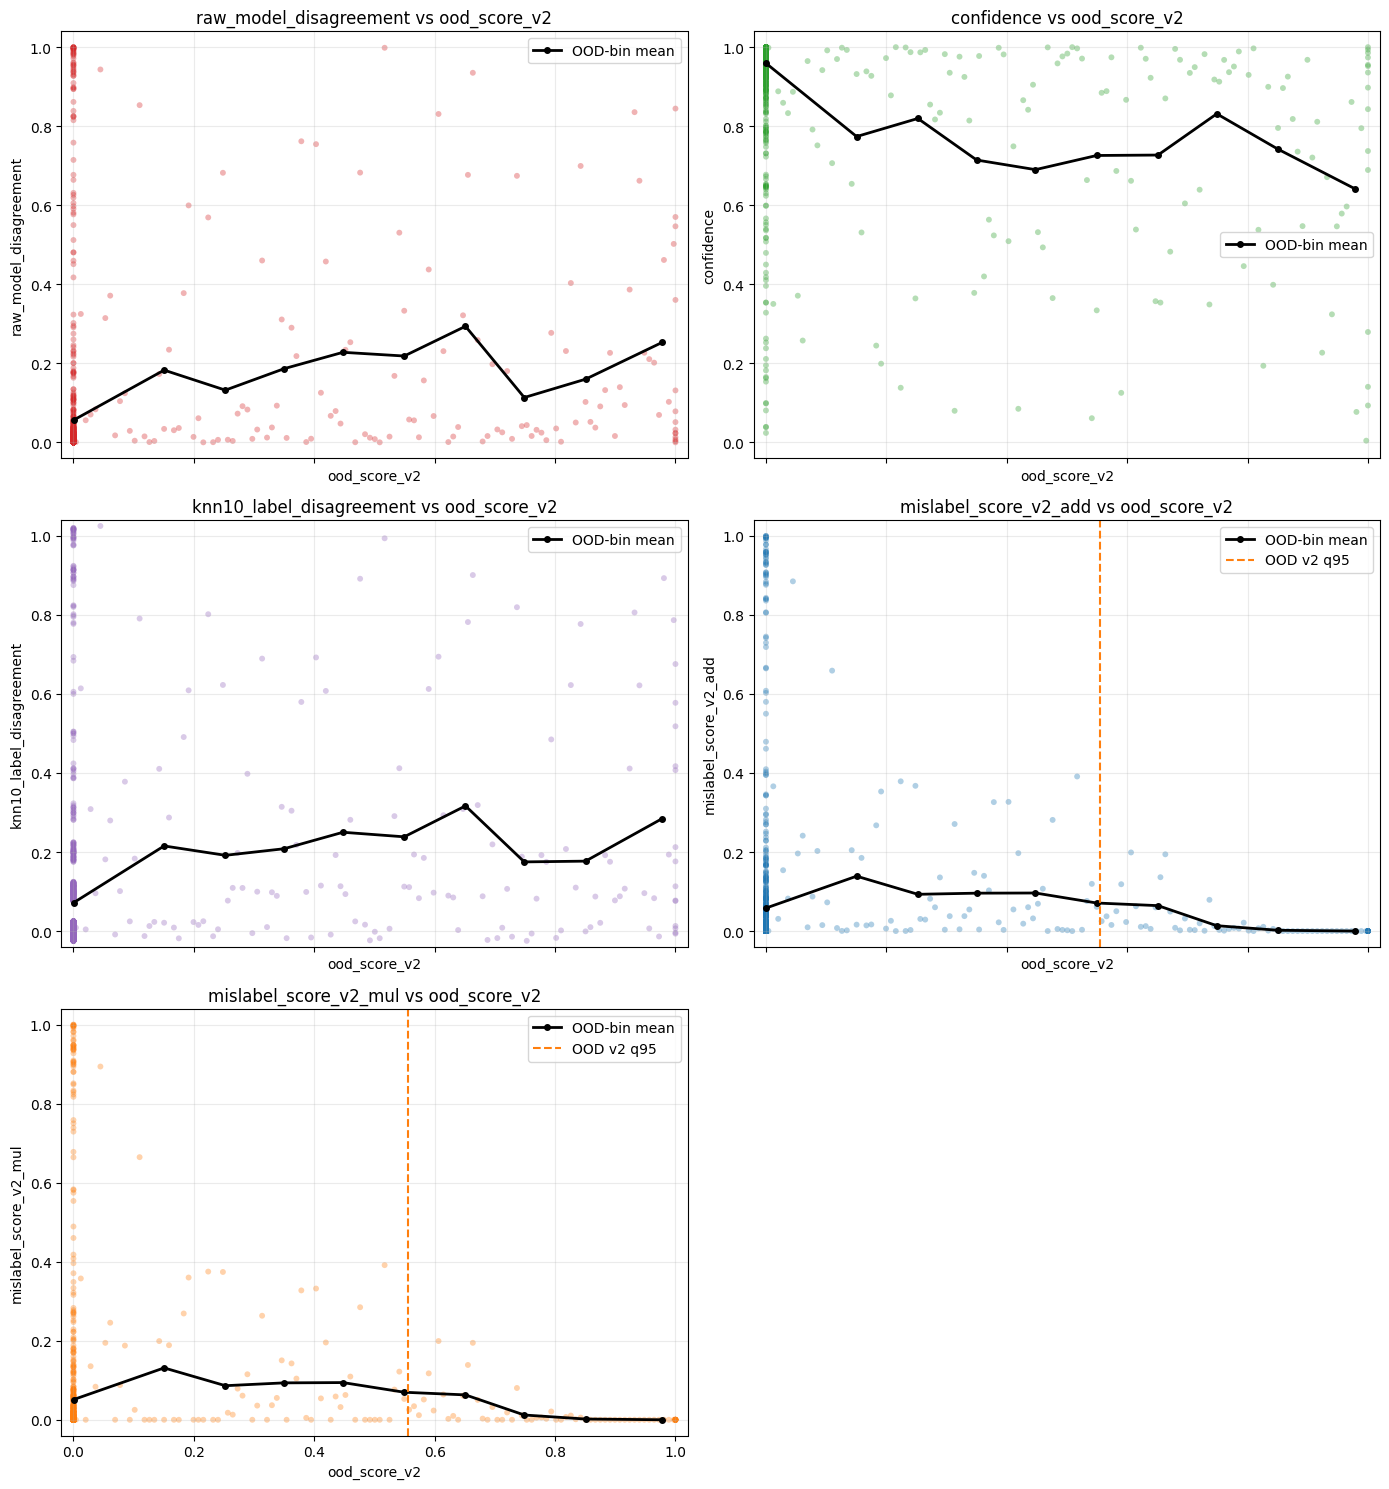

saved scatter plot: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/visualizations/v2_mislabel_diagnostics_vs_ood.png


In [10]:
def add_binned_mean_line(ax, df, x_col, y_col, bins=10):
    plot_df = df[[x_col, y_col]].dropna().copy()
    if plot_df.empty:
        return
    x_bins = pd.cut(plot_df[x_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    line_df = (
        plot_df.groupby(x_bins, observed=False)
        .agg(x_mean=(x_col, "mean"), y_mean=(y_col, "mean"), count=(y_col, "size"))
        .dropna(subset=["x_mean", "y_mean"])
        .reset_index(drop=True)
    )
    if not line_df.empty:
        ax.plot(line_df["x_mean"], line_df["y_mean"], color="black", linewidth=2, marker="o", markersize=4, label="OOD-bin mean")
        ax.legend(loc="best")

def plot_vs_ood(ax, df, y_col, title, y_label=None, jitter_y=0.0, color="tab:blue"):
    plot_df = df[["ood_score_v2", y_col]].dropna().copy()
    x = plot_df["ood_score_v2"].to_numpy(dtype=float)
    y = plot_df[y_col].to_numpy(dtype=float)
    y_plot = y
    if jitter_y > 0:
        rng = np.random.default_rng(SEED)
        y_plot = np.clip(y + rng.uniform(-jitter_y, jitter_y, size=len(y)), -0.04, 1.04)
    ax.scatter(x, y_plot, s=18, alpha=0.35, color=color, edgecolors="none")
    add_binned_mean_line(ax, plot_df, "ood_score_v2", y_col)
    ax.set_title(title)
    ax.set_xlabel("ood_score_v2")
    ax.set_ylabel(y_label or y_col)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True)
axes = axes.reshape(-1)
plot_vs_ood(axes[0], score_df, "raw_model_disagreement", "raw_model_disagreement vs ood_score_v2", color="tab:red")
plot_vs_ood(axes[1], score_df, "confidence", "confidence vs ood_score_v2", color="tab:green")
plot_vs_ood(axes[2], score_df, "knn10_label_disagreement", "knn10_label_disagreement vs ood_score_v2", jitter_y=0.025, color="tab:purple")
plot_vs_ood(axes[3], score_df, "mislabel_score_v2_add", "mislabel_score_v2_add vs ood_score_v2", color="tab:blue")
plot_vs_ood(axes[4], score_df, "mislabel_score_v2_mul", "mislabel_score_v2_mul vs ood_score_v2", color="tab:orange")
axes[5].axis("off")

for ax in [axes[3], axes[4]]:
    ax.axvline(float(score_df["ood_score_v2"].quantile(0.95)), color="tab:orange", linestyle="--", linewidth=1.5, label="OOD v2 q95")
    ax.legend(loc="best")

plt.tight_layout()
SCATTER_PLOT_PATH = VIS_DIR / "v2_mislabel_diagnostics_vs_ood.png"
fig.savefig(SCATTER_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("saved scatter plot:", SCATTER_PLOT_PATH)


## 9. top50 이미지 export

v1/v2 score별 top50 이미지를 별도 폴더에 복사하고, 각 score별 contact sheet를 저장한다. add/mul mislabel 후보를 육안으로 비교하기 위한 출력이다.


In [11]:
def load_rgb(path):
    return Image.open(path).convert("RGB")

def safe_score_text(value, digits=4):
    return f"{float(value):.{digits}f}".replace("-", "m").replace(".", "p")

def safe_filename_part(value, max_len=80):
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
    return (text[:max_len] or "na")

def copy_top_images(df, score_col, n=50):
    score_dir = TOP50_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = []
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        src_path = Path(row["path"])
        suffix = src_path.suffix if src_path.suffix else ".jpg"
        dst_name = (
            f"rank{rank:03d}_{score_col}_{safe_score_text(row[score_col])}_"
            f"{safe_filename_part(row['id'])}_label{int(row['label'])}_pred{int(row['pred_label'])}{suffix}"
        )
        dst_path = score_dir / dst_name
        if not src_path.exists():
            raise FileNotFoundError(src_path)
        shutil.copy2(src_path, dst_path)
        rows.append({
            "score_col": score_col,
            "rank": rank,
            "id": row["id"],
            "score": float(row[score_col]),
            "label": int(row["label"]),
            "pred_label": int(row["pred_label"]),
            "dup_score": float(row["dup_score"]),
            "ood_score_v2": float(row["ood_score_v2"]),
            "mislabel_score_v2_add": float(row["mislabel_score_v2_add"]),
            "mislabel_score_v2_mul": float(row["mislabel_score_v2_mul"]),
            "source_path": str(src_path),
            "copied_path": str(dst_path),
        })
    return pd.DataFrame(rows)

def save_top_grid(df, score_col, n=50, cols=10):
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = math.ceil(len(top) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.6 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (rank, (_, row)) in zip(axes, enumerate(top.iterrows(), start=1)):
        ax.imshow(load_rgb(row["path"]))
        ax.set_title(
            f"#{rank} {row['id']}\n{score_col}={row[score_col]:.3f}\nlabel={int(row['label'])} pred={int(row['pred_label'])}",
            fontsize=7,
        )
    plt.tight_layout()
    save_path = VIS_DIR / f"top50_{score_col}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path

top50_export_cols = ["ood_score_v1", "ood_score_v2", "mislabel_score_v1", "mislabel_score_v2_add", "mislabel_score_v2_mul"]
top50_index_parts = []
grid_paths = []
for col in top50_export_cols:
    top50_index_parts.append(copy_top_images(score_df, col, n=50))
    grid_paths.append({"score_col": col, "grid_path": str(save_top_grid(score_df, col, n=50, cols=10))})

top50_index = pd.concat(top50_index_parts, ignore_index=True)
top50_index.to_csv(TOP50_INDEX_PATH, index=False)
grid_df = pd.DataFrame(grid_paths)
grid_df.to_csv(TABLE_DIR / "top50_grid_paths.csv", index=False)

print("saved top50 index:", TOP50_INDEX_PATH)
display(top50_index.groupby("score_col").size().reset_index(name="copied_count"))
display(grid_df)


saved top50 index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/top50_images/top50_image_index.csv


,score_col,copied_count
0,mislabel_score_v1,50
1,mislabel_score_v2_add,50
2,mislabel_score_v2_mul,50
3,ood_score_v1,50
4,ood_score_v2,50


,score_col,grid_path
0,ood_score_v1,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1,ood_score_v2,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
2,mislabel_score_v1,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
3,mislabel_score_v2_add,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
4,mislabel_score_v2_mul,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


## 10. score-bin 분포와 구간별 샘플 폴더 export

`outlier_dup_pair_stats`에서 보던 방식처럼 score를 0.05 단위 bin으로 나누어 분포와 대표 샘플을 확인한다. 출력은 v2 전용 폴더에 저장한다.


,score_bin,count,score_min,score_max,score_mean,confidence_median,raw_model_disagreement_median,knn10_label_disagreement_median,dup_positive,score_col,ratio
0,0.00-0.05,1211,0.000000,0.000000,0.000000,0.996234,0.001917,0.00,0,dup_score,0.886530
1,0.05-0.10,14,0.062500,0.062500,0.062500,0.999953,0.000023,0.00,14,dup_score,0.010249
4,0.20-0.25,16,0.250000,0.250000,0.250000,0.998897,0.000551,0.00,16,dup_score,0.011713
11,0.55-0.60,36,0.562500,0.562500,0.562500,0.997760,0.001219,0.00,36,dup_score,0.026354
19,0.95-1.00,89,1.000000,1.000000,1.000000,0.998672,0.000698,0.00,89,dup_score,0.065154
20,0.00-0.05,1235,0.000000,0.044770,0.000119,0.997551,0.001283,0.00,147,ood_score_v2,0.904100
21,0.05-0.10,6,0.052910,0.093610,0.073260,0.771481,0.114260,0.15,1,ood_score_v2,0.004392
22,0.10-0.15,6,0.101750,0.142450,0.122100,0.980817,0.009592,0.10,0,ood_score_v2,0.004392
23,0.15-0.20,7,0.150590,0.199430,0.175010,0.927393,0.036303,0.00,2,ood_score_v2,0.005124
24,0.20-0.25,6,0.207570,0.248270,0.227920,0.932592,0.033704,0.00,1,ood_score_v2,0.004392


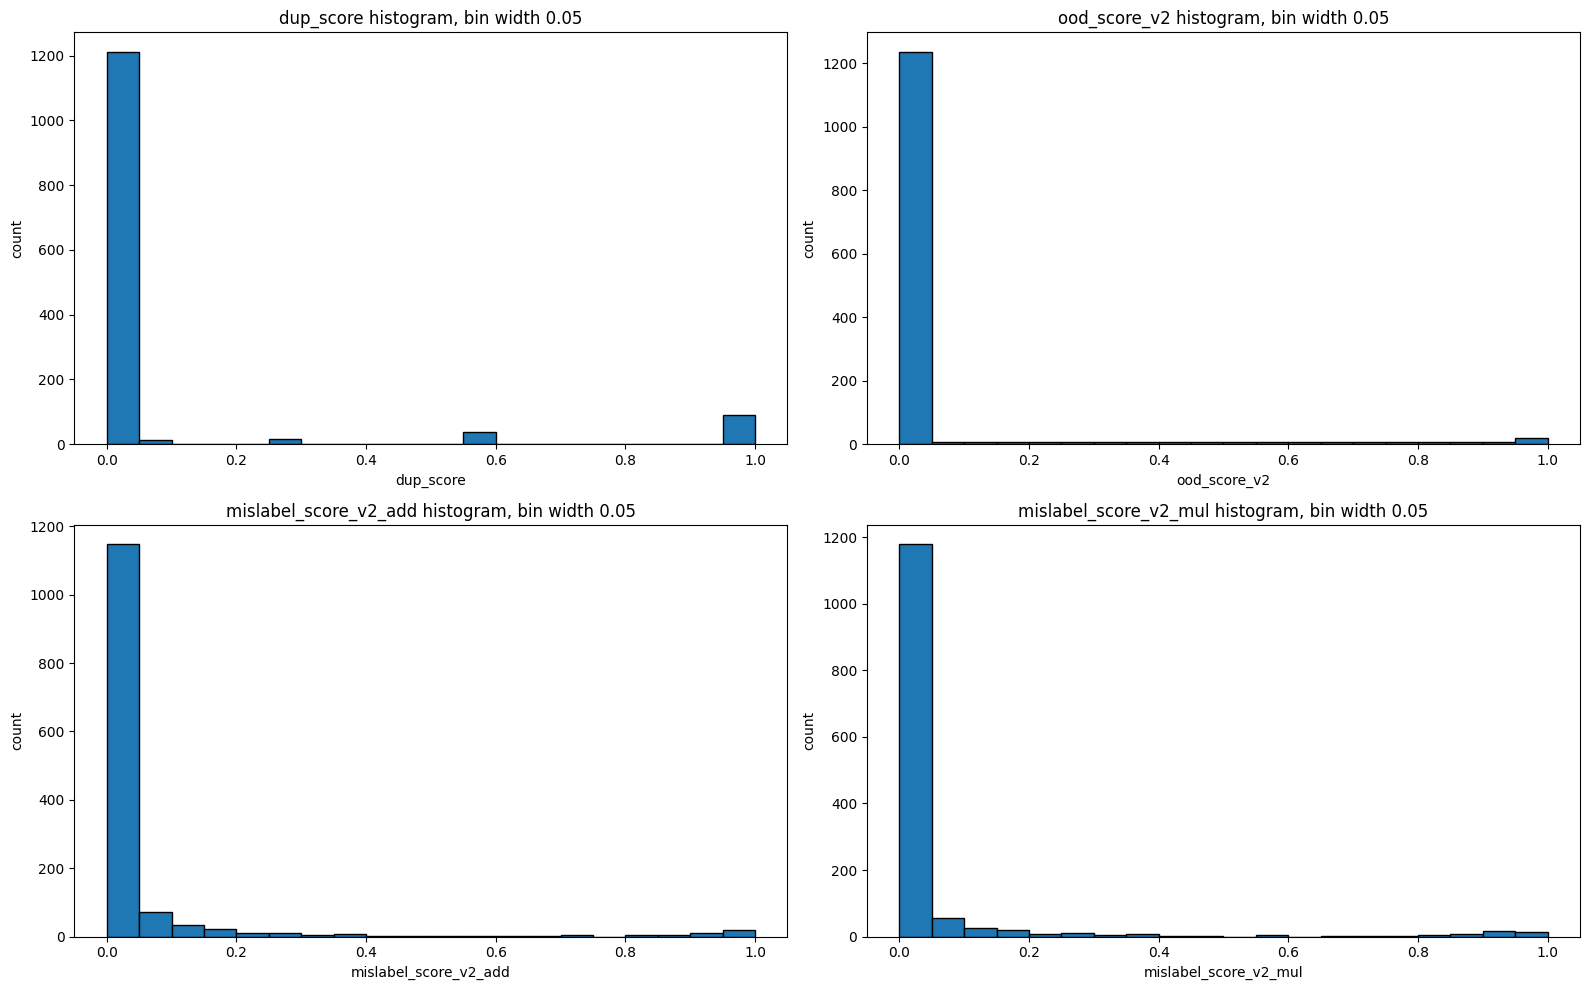

saved score-bin histogram: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/visualizations/score_bin_histograms.png
saved score-bin sample index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/score_bin_sample_exports/score_sample_index.csv


,score_col,score_bin,sample_count
0,dup_score,0.00-0.05,5
1,dup_score,0.05-0.10,5
2,dup_score,0.20-0.25,5
3,dup_score,0.55-0.60,5
4,dup_score,0.95-1.00,5
5,mislabel_score_v2_add,0.00-0.05,5
6,mislabel_score_v2_add,0.05-0.10,5
7,mislabel_score_v2_add,0.10-0.15,5
8,mislabel_score_v2_add,0.15-0.20,5
9,mislabel_score_v2_add,0.20-0.25,5


In [12]:
score_bin_edges = np.round(np.linspace(0.0, 1.0, 21), 2)
score_bin_labels = [f"{score_bin_edges[i]:.2f}-{score_bin_edges[i + 1]:.2f}" for i in range(len(score_bin_edges) - 1)]
score_bin_export_cols = ["dup_score", "ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul"]

for col in score_bin_export_cols:
    score_df[f"{col}_bin"] = pd.cut(score_df[col], bins=score_bin_edges, labels=score_bin_labels, include_lowest=True)

def make_score_bin_stats(df, score_col):
    bin_col = f"{score_col}_bin"
    stats = (
        df.groupby(bin_col, observed=False)
        .agg(
            count=("id", "size"),
            score_min=(score_col, "min"),
            score_max=(score_col, "max"),
            score_mean=(score_col, "mean"),
            confidence_median=("confidence", "median"),
            raw_model_disagreement_median=("raw_model_disagreement", "median"),
            knn10_label_disagreement_median=("knn10_label_disagreement", "median"),
            dup_positive=("dup_score", lambda s: int((s > 0).sum())),
        )
        .reset_index()
        .rename(columns={bin_col: "score_bin"})
    )
    stats["score_col"] = score_col
    stats["ratio"] = stats["count"] / len(df)
    return stats

score_bin_stats = pd.concat([make_score_bin_stats(score_df, col) for col in score_bin_export_cols], ignore_index=True)
score_bin_stats.to_csv(TABLE_DIR / "score_bin_stats.csv", index=False)
display(score_bin_stats.query("count > 0"))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.reshape(-1)
for ax, col in zip(axes, score_bin_export_cols):
    ax.hist(score_df[col], bins=score_bin_edges, edgecolor="black")
    ax.set_title(f"{col} histogram, bin width 0.05")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
plt.tight_layout()
SCORE_BIN_HIST_PATH = VIS_DIR / "score_bin_histograms.png"
fig.savefig(SCORE_BIN_HIST_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("saved score-bin histogram:", SCORE_BIN_HIST_PATH)

def bin_folder_name(rank, bin_label):
    lo, hi = str(bin_label).split("-")
    return f"bin_{rank:02d}_{safe_filename_part(lo)}_{safe_filename_part(hi)}"

def export_score_bin_samples(df, score_col, n_per_bin=5):
    bin_col = f"{score_col}_bin"
    score_dir = SCORE_SAMPLE_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)
    exported_rows = []
    ranked_df = df.sort_values(score_col, ascending=False).copy()
    for bin_rank, bin_label in enumerate(reversed(score_bin_labels), start=1):
        bin_df = ranked_df[ranked_df[bin_col].astype(str).eq(str(bin_label))]
        if bin_df.empty:
            continue
        bin_dir = score_dir / bin_folder_name(bin_rank, bin_label)
        bin_dir.mkdir(parents=True, exist_ok=True)
        for local_rank, (_, row) in enumerate(bin_df.head(n_per_bin).iterrows(), start=1):
            src_path = Path(row["path"])
            suffix = src_path.suffix if src_path.suffix else ".jpg"
            dst_name = (
                f"rank{local_rank:02d}_{score_col}_{safe_score_text(row[score_col])}_"
                f"{safe_filename_part(row['id'])}_label{int(row['label'])}_pred{int(row['pred_label'])}{suffix}"
            )
            dst_path = bin_dir / dst_name
            if not src_path.exists():
                raise FileNotFoundError(src_path)
            shutil.copy2(src_path, dst_path)
            exported_rows.append({
                "score_col": score_col,
                "score_bin": str(bin_label),
                "bin_rank_high_to_low": bin_rank,
                "rank_in_bin": local_rank,
                "id": row["id"],
                "score": float(row[score_col]),
                "label": int(row["label"]),
                "pred_label": int(row["pred_label"]),
                "copied_path": str(dst_path),
            })
    return pd.DataFrame(exported_rows)

score_sample_index = pd.concat([export_score_bin_samples(score_df, col, n_per_bin=5) for col in score_bin_export_cols], ignore_index=True)
score_sample_index.to_csv(SCORE_SAMPLE_INDEX_PATH, index=False)
print("saved score-bin sample index:", SCORE_SAMPLE_INDEX_PATH)
display(score_sample_index.groupby(["score_col", "score_bin"]).size().reset_index(name="sample_count"))


## 11. dup / near-miss 진단 내장

v2에서는 dup을 바꾸지 않지만, OOD/Mislabel 변화와 함께 볼 수 있도록 기존 dup 관련 진단을 같은 노트북에 둔다.


In [13]:
dup_df = score_df[score_df["dup_score"] > 0].copy().reset_index(drop=True)
nondup_df = score_df[score_df["dup_score"] <= 0].copy().reset_index(drop=True)

summary_df = pd.DataFrame([
    {"metric": "total_samples", "value": len(score_df)},
    {"metric": "dup_candidates", "value": len(dup_df)},
    {"metric": "dup_candidate_ratio", "value": len(dup_df) / len(score_df)},
    {"metric": "label_conflict_count_dup_positive", "value": int(dup_df["label_conflict"].fillna(False).sum())},
])
display(summary_df)

dup_score_columns = ["dup_score", "resnet18_dup_score", "phash_dup_score", "nearest_phash_dist", "embedding_knn1_cos"]
display(score_df[dup_score_columns].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

source_stats = score_df["dup_source"].value_counts(dropna=False).rename_axis("dup_source").reset_index(name="count")
source_stats["ratio"] = source_stats["count"] / len(score_df)
display(source_stats)

near_miss_by_cos = (
    nondup_df.sort_values("embedding_knn1_cos", ascending=False)
    .loc[:, [
        "id", "embedding_knn1_id", "label", "embedding_knn1_label",
        "dup_score", "embedding_knn1_cos", "resnet18_dup_score", "phash_dup_score",
        "nearest_phash_dist", "ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul", "path",
    ]]
    .head(30)
)
print("Top non-dup rows by embedding_knn1_cos")
display(near_miss_by_cos)

near_miss_by_phash = (
    nondup_df.sort_values("nearest_phash_dist", ascending=True)
    .loc[:, [
        "id", "label", "pred_label", "dup_score", "embedding_knn1_cos",
        "resnet18_dup_score", "phash_dup_score", "nearest_phash_dist",
        "ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul", "path",
    ]]
    .head(30)
)
print("Top non-dup rows by nearest_phash_dist")
display(near_miss_by_phash)


,metric,value
0,total_samples,1366.00000
1,dup_candidates,155.00000
2,dup_candidate_ratio,0.11347
3,label_conflict_count_dup_positive,20.00000


,count,mean,std,min,50%,90%,95%,99%,max
dup_score,1366.0,0.083547,0.259487,0.000000,0.00000,0.250000,1.000000,1.000000,1.000000
resnet18_dup_score,1366.0,0.004813,0.045150,0.000000,0.00000,0.000000,0.000000,0.175129,0.834529
phash_dup_score,1366.0,0.083547,0.259487,0.000000,0.00000,0.250000,1.000000,1.000000,1.000000
nearest_phash_dist,1366.0,15.364568,5.485942,0.000000,18.00000,20.000000,20.000000,20.000000,22.000000
embedding_knn1_cos,1366.0,0.854860,0.073043,0.668569,0.83576,0.972554,0.988794,0.998071,0.999717


,dup_source,count,ratio
0,none,1211,0.88653
1,phash,155,0.11347


Top non-dup rows by embedding_knn1_cos


,id,embedding_knn1_id,label,embedding_knn1_label,dup_score,embedding_knn1_cos,resnet18_dup_score,phash_dup_score,nearest_phash_dist,ood_score_v2,mislabel_score_v2_add,mislabel_score_v2_mul,path
690,train_00779,train_00162,0,0,0.0,0.992599,0.0,0.0,12.0,0.000000,2.731157e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
142,train_00162,train_00779,0,0,0.0,0.992599,0.0,0.0,14.0,0.000000,3.291104e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
939,train_01052,train_00080,1,1,0.0,0.988372,0.0,0.0,10.0,0.000000,2.973988e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
72,train_00080,train_01052,1,1,0.0,0.988372,0.0,0.0,10.0,0.000000,2.671519e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
281,train_00317,train_01361,1,1,0.0,0.988186,0.0,0.0,16.0,0.264550,2.902012e-02,0.012988,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1206,train_01361,train_00317,1,1,0.0,0.988186,0.0,0.0,18.0,0.000000,4.131901e-02,0.014827,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
395,train_00444,train_01084,1,1,0.0,0.985995,0.0,0.0,16.0,0.000000,1.483129e-05,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
965,train_01084,train_00444,1,1,0.0,0.985995,0.0,0.0,16.0,0.000000,2.620771e-06,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
477,train_00539,train_00778,0,0,0.0,0.984100,0.0,0.0,14.0,0.000000,7.605164e-06,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
689,train_00778,train_00539,0,0,0.0,0.984100,0.0,0.0,14.0,0.000000,1.957499e-05,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


Top non-dup rows by nearest_phash_dist


,id,label,pred_label,dup_score,embedding_knn1_cos,resnet18_dup_score,phash_dup_score,nearest_phash_dist,ood_score_v2,mislabel_score_v2_add,mislabel_score_v2_mul,path
77,train_00086,1,1,0.0,0.966474,0.0,0.0,8.0,0.557591,2.499498e-02,0.025380,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1066,train_01205,1,1,0.0,0.966474,0.0,0.0,8.0,0.687831,1.801565e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
541,train_00610,1,1,0.0,0.971083,0.0,0.0,8.0,0.000000,1.449372e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
960,train_01077,1,1,0.0,0.971083,0.0,0.0,8.0,0.000000,2.534781e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
977,train_01097,1,1,0.0,0.794318,0.0,0.0,8.0,0.000000,1.050928e-02,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
405,train_00455,0,0,0.0,0.809590,0.0,0.0,8.0,0.000000,1.312559e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
224,train_00250,0,0,0.0,0.924067,0.0,0.0,10.0,0.000000,3.007991e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
72,train_00080,1,1,0.0,0.988372,0.0,0.0,10.0,0.000000,2.671519e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
630,train_00715,0,0,0.0,0.943634,0.0,0.0,10.0,0.000000,1.969195e-05,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
41,train_00046,1,1,0.0,0.960729,0.0,0.0,10.0,0.000000,7.406386e-03,0.000000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


## 12. 최종 검증과 정리

새 산출물은 모두 v2 출력 폴더 아래에 저장된다. v1 출력 폴더와 제출 원본 파일은 덮어쓰지 않는다.


In [14]:
validate_submission(submission_add, sample)
validate_submission(submission_mul, sample)

for path in [DETAIL_V2_PATH, SUBMISSION_DEFAULT_PATH, SUBMISSION_ADD_PATH, SUBMISSION_MUL_PATH, CONFIG_PATH, TOP50_INDEX_PATH, SCORE_SAMPLE_INDEX_PATH, SCATTER_PLOT_PATH, SCORE_BIN_HIST_PATH]:
    if not Path(path).exists():
        raise FileNotFoundError(path)

if score_df[["ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul", "dup_score"]].isna().any().any():
    raise ValueError("v2 score columns contain NaN")
if not score_df[["ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul", "dup_score"]].apply(lambda s: s.between(0, 1).all()).all():
    raise ValueError("v2 scores must be in [0, 1]")

print("Final validation passed.")
print("OUTPUT_DIR:", OUTPUT_DIR)
print("detail:", DETAIL_V2_PATH)
print("default submission(add):", SUBMISSION_DEFAULT_PATH)
print("add submission:", SUBMISSION_ADD_PATH)
print("mul submission:", SUBMISSION_MUL_PATH)
print("top50 image folders:", TOP50_DIR)
print("score-bin sample folders:", SCORE_SAMPLE_DIR)
print("tables:", TABLE_DIR)

final_summary = pd.DataFrame({
    "score": ["ood_score_v2", "mislabel_score_v2_add", "mislabel_score_v2_mul", "dup_score"],
    "nonzero_count": [
        int((score_df["ood_score_v2"] > 0).sum()),
        int((score_df["mislabel_score_v2_add"] > 0).sum()),
        int((score_df["mislabel_score_v2_mul"] > 0).sum()),
        int((score_df["dup_score"] > 0).sum()),
    ],
    "max": [
        float(score_df["ood_score_v2"].max()),
        float(score_df["mislabel_score_v2_add"].max()),
        float(score_df["mislabel_score_v2_mul"].max()),
        float(score_df["dup_score"].max()),
    ],
})
display(final_summary)


Final validation passed.
OUTPUT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101
detail: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/trackB_v2_scores_detail.csv
default submission(add): /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB.csv
add submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB_v2_add.csv
mul submission: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/submissionB_v2_mul.csv
top50 image folders: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/top50_images
score-bin sample folders: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/score_bin_sample_exports
tables: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Ques

,score,nonzero_count,max
0,ood_score_v2,137,1.000000
1,mislabel_score_v2_add,1333,0.999970
2,mislabel_score_v2_mul,356,0.999975
3,dup_score,155,1.000000


## 13. mislabel top100 이미지 export


In [15]:
MISLABEL_TOP100_N = 100
MISLABEL_TOP100_COLS = ["mislabel_score_v2_add", "mislabel_score_v2_mul"]
MISLABEL_TOP100_DIR = OUTPUT_DIR / "mislabel_top100_images"
MISLABEL_TOP100_INDEX_PATH = TABLE_DIR / "mislabel_top100_image_index.csv"

MISLABEL_TOP100_DIR.mkdir(parents=True, exist_ok=True)
VIS_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

missing_cols = [col for col in MISLABEL_TOP100_COLS if col not in score_df.columns]
if missing_cols:
    raise ValueError(f"Missing mislabel top100 score columns: {missing_cols}")

# Fallbacks make this final block runnable on its own after score_df/paths are restored.
if "load_rgb" not in globals():
    def load_rgb(path):
        return Image.open(path).convert("RGB")

if "safe_score_text" not in globals():
    def safe_score_text(value, digits=4):
        return f"{float(value):.{digits}f}".replace("-", "m").replace(".", "p")

if "safe_filename_part" not in globals():
    def safe_filename_part(value, max_len=80):
        text = str(value)
        text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
        return (text[:max_len] or "na")

if "display" not in globals():
    from IPython.display import display


def copy_mislabel_top100_images(df, score_col, n=MISLABEL_TOP100_N):
    score_dir = MISLABEL_TOP100_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = []
    for rank, (_, row) in enumerate(top.iterrows(), start=1):
        src_path = Path(row["path"])
        suffix = src_path.suffix if src_path.suffix else ".jpg"
        dst_name = (
            f"rank{rank:03d}_{score_col}_{safe_score_text(row[score_col])}_"
            f"{safe_filename_part(row['id'])}_label{int(row['label'])}_pred{int(row['pred_label'])}{suffix}"
        )
        dst_path = score_dir / dst_name
        if not src_path.exists():
            raise FileNotFoundError(src_path)
        shutil.copy2(src_path, dst_path)
        rows.append({
            "score_col": score_col,
            "rank": rank,
            "id": row["id"],
            "score": float(row[score_col]),
            "label": int(row["label"]),
            "pred_label": int(row["pred_label"]),
            "confidence": float(row["confidence"]),
            "ood_score_v2": float(row["ood_score_v2"]),
            "dup_score": float(row["dup_score"]),
            "source_path": str(src_path),
            "copied_path": str(dst_path),
        })
    return pd.DataFrame(rows)


def save_mislabel_top100_grid(df, score_col, n=MISLABEL_TOP100_N, cols=10):
    top = df.sort_values(score_col, ascending=False).head(n).copy()
    rows = math.ceil(len(top) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.6 * cols, 3.0 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (rank, (_, row)) in zip(axes, enumerate(top.iterrows(), start=1)):
        ax.imshow(load_rgb(row["path"]))
        ax.set_title(
            f"#{rank} {row['id']}\n{score_col}={row[score_col]:.3f}\nlabel={int(row['label'])} pred={int(row['pred_label'])}",
            fontsize=7,
        )
    plt.tight_layout()
    save_path = VIS_DIR / f"top100_{score_col}.png"
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return save_path

mislabel_top100_index_parts = []
mislabel_top100_grid_rows = []
for col in MISLABEL_TOP100_COLS:
    mislabel_top100_index_parts.append(copy_mislabel_top100_images(score_df, col, n=MISLABEL_TOP100_N))
    mislabel_top100_grid_rows.append({
        "score_col": col,
        "grid_path": str(save_mislabel_top100_grid(score_df, col, n=MISLABEL_TOP100_N, cols=10)),
    })

mislabel_top100_index = pd.concat(mislabel_top100_index_parts, ignore_index=True)
mislabel_top100_index.to_csv(MISLABEL_TOP100_INDEX_PATH, index=False)
mislabel_top100_grid_df = pd.DataFrame(mislabel_top100_grid_rows)
mislabel_top100_grid_df.to_csv(TABLE_DIR / "mislabel_top100_grid_paths.csv", index=False)

expected_top100_rows = len(MISLABEL_TOP100_COLS) * MISLABEL_TOP100_N
if len(mislabel_top100_index) != expected_top100_rows:
    raise ValueError(f"mislabel top100 index row count mismatch: {len(mislabel_top100_index)} != {expected_top100_rows}")
for col in MISLABEL_TOP100_COLS:
    copied_count = int((mislabel_top100_index["score_col"] == col).sum())
    if copied_count != MISLABEL_TOP100_N:
        raise ValueError(f"{col} copied count mismatch: {copied_count} != {MISLABEL_TOP100_N}")

print("saved mislabel top100 images:", MISLABEL_TOP100_DIR)
print("saved mislabel top100 index:", MISLABEL_TOP100_INDEX_PATH)
display(mislabel_top100_index.groupby("score_col").size().reset_index(name="copied_count"))
display(mislabel_top100_grid_df)

saved mislabel top100 images: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/mislabel_top100_images
saved mislabel top100 index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070103_v2_20260701_223101/tables/mislabel_top100_image_index.csv


,score_col,copied_count
0,mislabel_score_v2_add,100
1,mislabel_score_v2_mul,100


,score_col,grid_path
0,mislabel_score_v2_add,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1,mislabel_score_v2_mul,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
